In [25]:
%matplotlib widget
%matplotlib widget
import os
from pathlib import Path
import time
import torch
import numpy as np
import math
import gc
from functools import partial
from dataset_alt import Dataset, load_dataframes_from_folder, reverse_normalization
from torch.utils.data import DataLoader
from transformer_zerostep import GPTConfig, GPT, warmup_cosine_lr
import argparse
import warnings
import matplotlib.pyplot as plt
import copy


# set figure parameters
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['axes.labelsize']=14
plt.rcParams['xtick.labelsize']=11
plt.rcParams['ytick.labelsize']=11
plt.rcParams['axes.grid']=True
plt.rcParams['axes.xmargin']=0

In [26]:
# Overall settings
out_dir = "out"

model_name = "noise_h50_40k.pt"
# model_name = "model_high_speed.pt"

current_path = os.getcwd().split("in-context-bldc")[0]
data_path = os.path.join(current_path,"in-context-bldc", "data")

# folder = "simulated/50_percent_control_with_noise/validation"
# folder = "simulated/50_percent_control/validation"
# folder = "CL_experiments_double_sensor_control/test/inertia07"
# folder_path = os.path.join(data_path, folder)

data_folders = ["simulated/50_percent_control_with_noise/validation","simulated/50_percent_control_perturbed_with_noise/validation","simulated/50_percent_control_current_disturbance_with_noise/validation"]
# data_folders = ["simulated/50_percent_control/validation","simulated/50_percent_control_perturbed/validation","simulated/50_percent_control_current_disturbance/validation"]
# data_folders = ["CL_experiments_double_sensor_control/test/inertia13"]
folder_path_list = [os.path.join(data_path, folder) for folder in data_folders]

# Compute settings
cuda_device = "cuda:0"
no_cuda = False
threads = 10
compile = False

# Configure compute
torch.set_num_threads(threads) 
use_cuda = not no_cuda and torch.cuda.is_available()
device_name  = cuda_device if use_cuda else "cpu"
device = torch.device(device_name)
device_type = 'cuda' if 'cuda' in device_name else 'cpu' # for later use in torch.autocast
torch.set_float32_matmul_precision("high")
print(torch.cuda.is_available())
# Create out dir
out_dir = Path(out_dir)
exp_data = torch.load(out_dir/model_name, map_location=device, weights_only=False)
seq_len = exp_data["cfg"].seq_len
nx = exp_data["cfg"].nx
exp_data["iter_num"]
print(seq_len)
print(exp_data["iter_num"])
print(exp_data['best_val_loss'])
print(exp_data["cfg"])
print(exp_data["cfg"].lr)
print(exp_data["train_time"]/3600)


True
50
37331
0.0011266251094639301
Namespace(model_dir='out', out_file='noise_h50', in_file='noise_h50_10k', init_from='scratch', seed=42, log_wandb=False, nx=4, nu=6, ny=1, seq_len=50, mag_range=(0.5, 0.97), phase_range=(0.0, 1.5707963267948966), fixed_system=False, n_layer=8, n_head=4, n_embd=16, dropout=0, bias=False, batch_size=128, max_iters=40000, warmup_iters=5000, lr=1e-05, weight_decay=0.0, eval_interval=10, eval_iters=10, fixed_lr=False, threads=16, no_cuda=False, cuda_device='cuda:0', compile=False, beta1=0.9, beta2=0.95, block_size=50, lr_decay_iters=40000, min_lr=1.0000000000000002e-06, decay_lr=True, eval_batch_size=128)
1e-05
15.143221220042971


In [27]:
exp_data.keys()

dict_keys(['model', 'optimizer', 'model_args', 'iter_num', 'train_time', 'LOSS', 'LOSS_VAL', 'best_val_loss', 'cfg'])

In [28]:
# import pickle as pkl

# data_copy = copy.deepcopy(exp_data)
# print(list(data_copy['model'].keys()))
# checking_par = 'transformer.h.0.ln_2.weight'
# print(checking_par)
# print(data_copy['model'][checking_par].size())
# print(data_copy['model'][checking_par].cpu().numpy())

# data_to_save = data_copy['model']
# with open("test_pkl.pkl",'wb') as f:
#     pkl.dump(data_to_save, f)

# with open("test_pkl.pkl",'rb') as f:
#     data_stored = pkl.load(f)

# print(data_stored[checking_par].cpu().numpy())

number of parameters: 0.03M


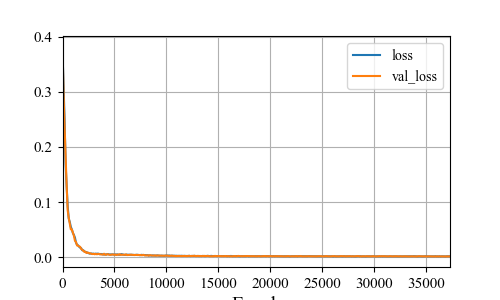

Model size in KB: 100.69140625


In [29]:
# generate the model
model_args = exp_data["model_args"]
gptconf = GPTConfig(**model_args)
model = GPT(gptconf).to(device)
# print(model.get_num_params())

state_dict = exp_data["model"]
unwanted_prefix = '_orig_mod.'
for k,v in list(state_dict.items()):
    if k.startswith(unwanted_prefix):
        state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
    if k.startswith('module.'):
        state_dict[k[7:]] = v
        state_dict.pop(k)

model.load_state_dict(state_dict)

#plot loss profile
plt.figure(figsize=(5,3))
plt.plot(np.arange(exp_data['iter_num'])[::100], exp_data['LOSS'][::100], label="loss")
plt.plot(np.arange(exp_data['iter_num'])[::100], exp_data['LOSS_VAL'][::100], label="val_loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

# compute model size
size_in_bytes = sum(param.numel() * param.element_size() for param in model.parameters())
size_in_bytes += sum(buffer.numel() * buffer.element_size() for buffer in model.buffers())

# Convert bytes to kilobytes
size_in_kb = size_in_bytes / 1024
print('Model size in KB:', size_in_kb)

40000


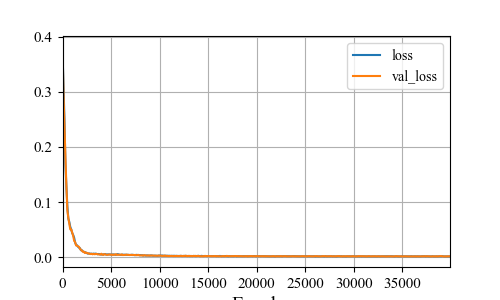

In [30]:
# plot the full training loss profile, if the model reached the final iteration during training
try:
    model_name_check = model_name[:-6] + "loss_check.pt"
    exp_data_check = torch.load(out_dir/model_name_check, map_location=device, weights_only=False)
    # print(model_name_check)
    print(exp_data_check["iter_num"])
    
    plt.figure(figsize=(5,3))
    plt.plot(np.arange(exp_data_check['iter_num'])[::100], exp_data_check['LOSS'][::100], label="loss")
    plt.plot(np.arange(exp_data_check['iter_num'])[::100], exp_data_check['LOSS_VAL'][::100], label="val_loss")
    plt.xlabel("Epoch")
    plt.legend()
    plt.show()
    
except Exception as e:
    print(e)

In [31]:
# assemble the data


# dfs = load_dataframes_from_folder(folder_path)
# # Log the number of DataFrames loaded
# print(f"Loaded {len(dfs)} DataFrames from {folder_path}.") 


dfs = []
for path_iter in folder_path_list:
    new_dfs = load_dataframes_from_folder(path_iter)
    dfs = dfs + new_dfs
    print(f"Loaded {len(new_dfs)} DataFrames from {path_iter}.") 

H = exp_data["cfg"].seq_len # context window length
# Create an instance of the dataset
dataset_exp = Dataset(dfs=dfs, seq_len=H)
dataloader = DataLoader(dataset_exp, batch_size=exp_data["cfg"].batch_size, shuffle=True)


Loaded 245 DataFrames from c:\Users\39340\Documents\GitHub\in-context-bldc\data\simulated/50_percent_control_with_noise/validation.
Loaded 243 DataFrames from c:\Users\39340\Documents\GitHub\in-context-bldc\data\simulated/50_percent_control_perturbed_with_noise/validation.
Loaded 248 DataFrames from c:\Users\39340\Documents\GitHub\in-context-bldc\data\simulated/50_percent_control_current_disturbance_with_noise/validation.


In [32]:
## test each experiment
df_len = len(dfs)
rmse = np.zeros(df_len)
u_full_all = []
y_full_all = []

# extract and stack all the experiments profiles
for i in range(df_len):
    u_full, y_full = dataset_exp.get_full_experiment(i)
    u_full, y_full = u_full.to(device), y_full.to(device)

    u_full_all.append(u_full)
    y_full_all.append(y_full)

u_full_all = torch.stack(u_full_all, dim=0)
y_full_all = torch.stack(y_full_all, dim=0)
y_pred_all = torch.zeros_like(y_full_all)



with torch.no_grad():
    
    # j index moves along the experiments time instants
    for j in range(y_full_all.shape[1]):
        
        # at time instant j
        # if the number of available samples < the context window, the model is fed only those samples
        if j < H:
            input_val = u_full_all[:, :j+1, :] # first j samples of the experiment

            pred = model(input_val)[:,-1,:] #we consider only the last value of the model estimation
        else:
            input_val = u_full_all[:,j-H+1:j+1, :]

            pred = model(input_val)[:,-1,:] #we consider only the last value of the model estimation
        
        
        y_pred_all[:,j,0] = pred[:,0] # the list of estimations is updated
        
    # input output and predictions are converted back to their original range of values
    u_full_all, y_full_all, y_pred_all  = reverse_normalization(u_full_all, y_full_all, y_pred_all)


In [33]:

# compute the rmse for each experiment, and produce its average
for i in range(df_len):
    y_tmp = y_full_all[i,:,:].cpu().numpy()
    y_pred_tmp = y_pred_all[i,:,:].cpu().numpy()
    rmse[i] = np.sqrt(((y_tmp-y_pred_tmp)**2).mean())

print("Average rmse: ", rmse.mean())


Average rmse:  0.33199261141050124


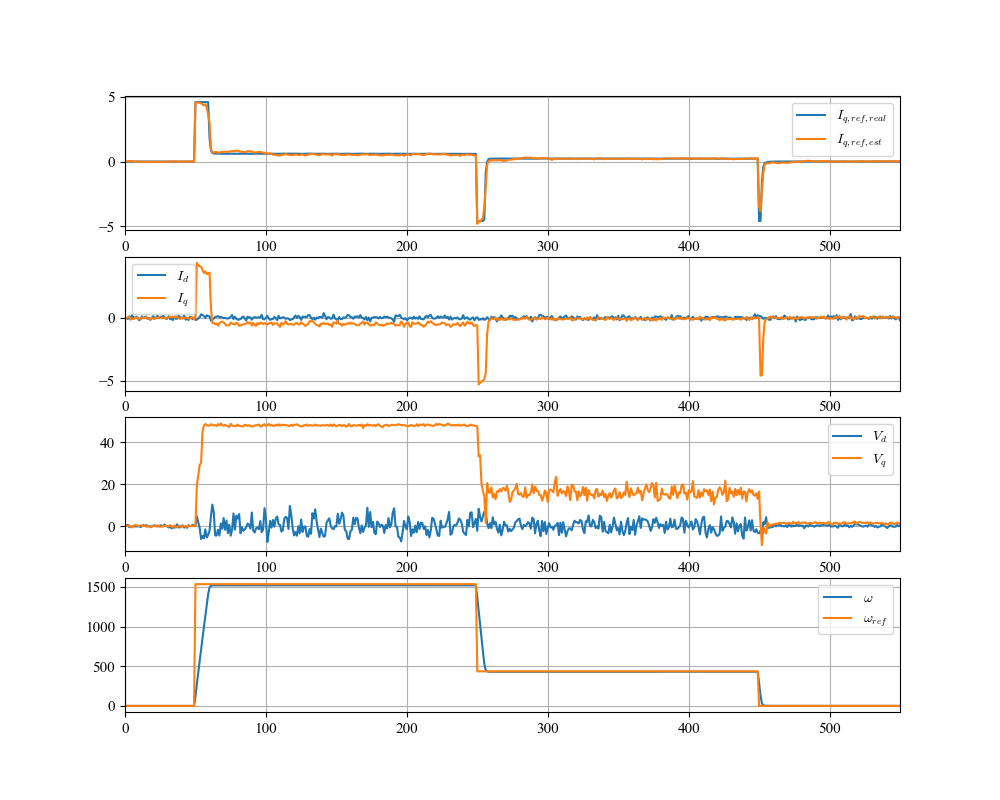

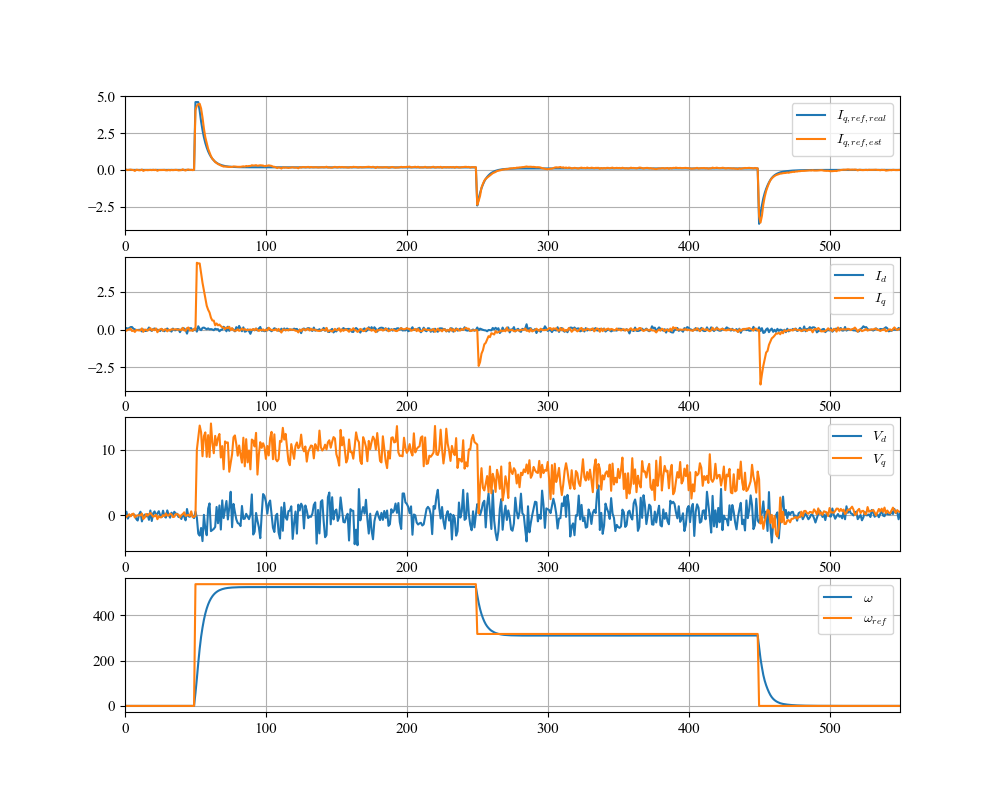

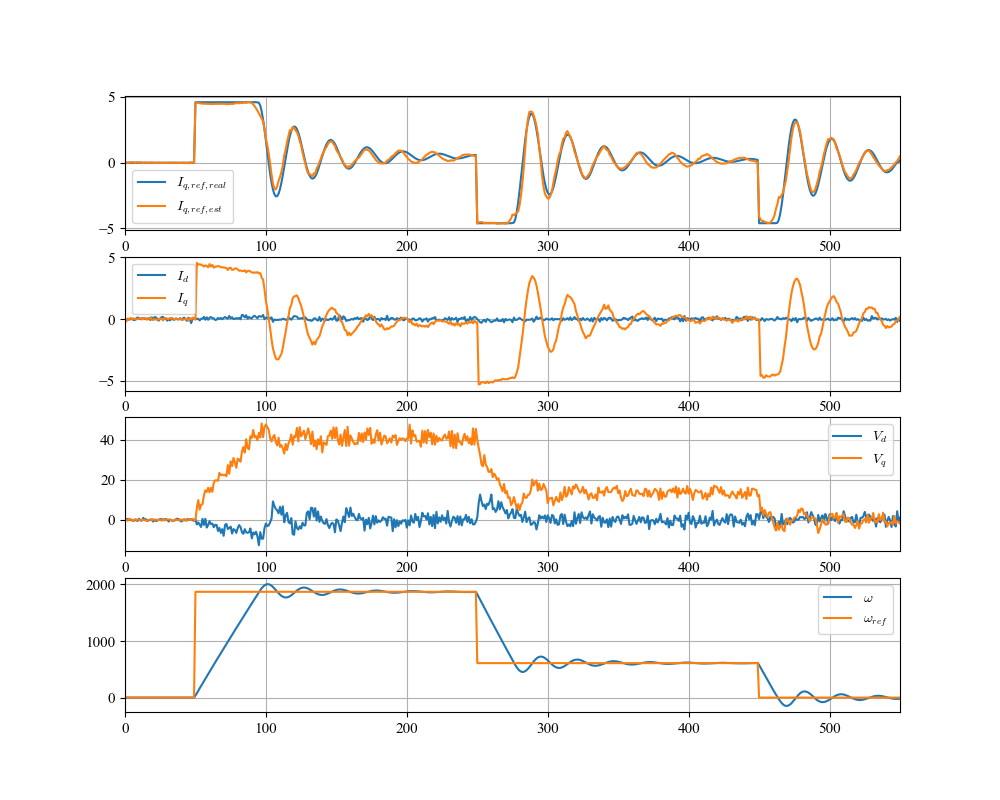

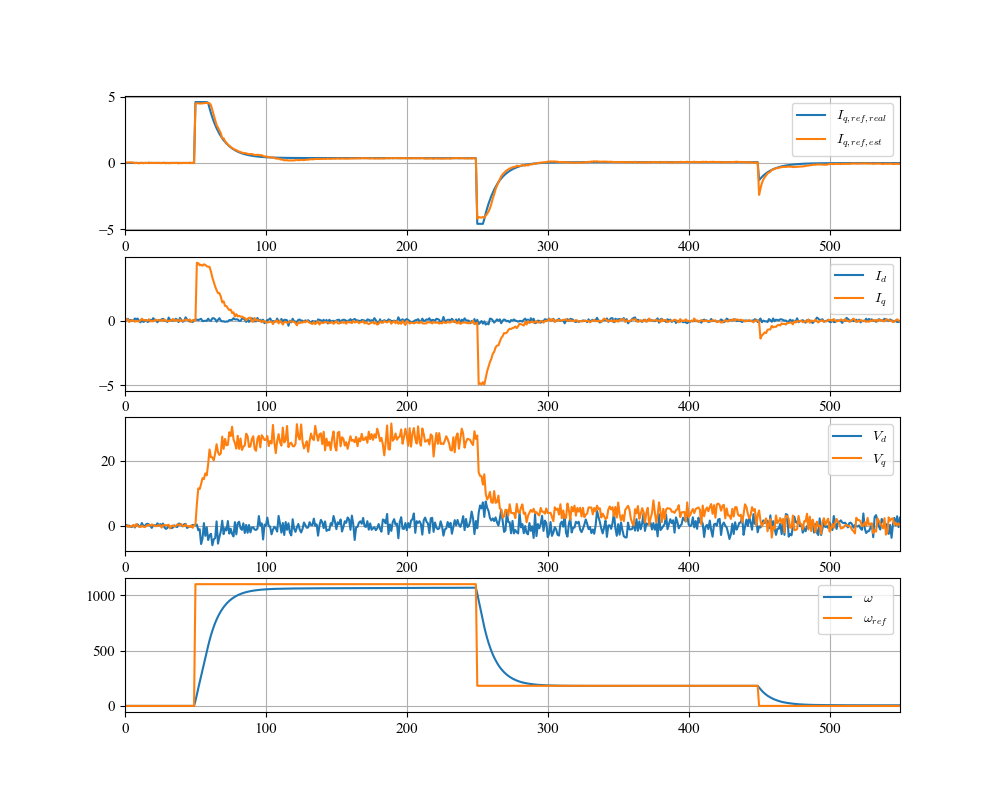

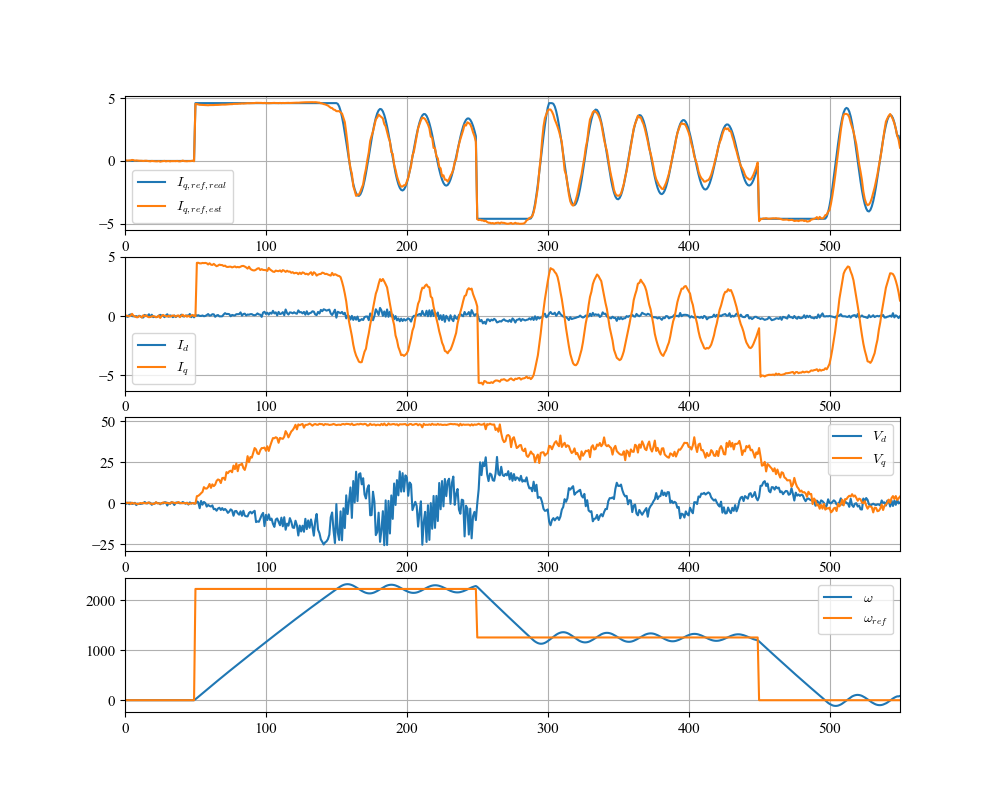

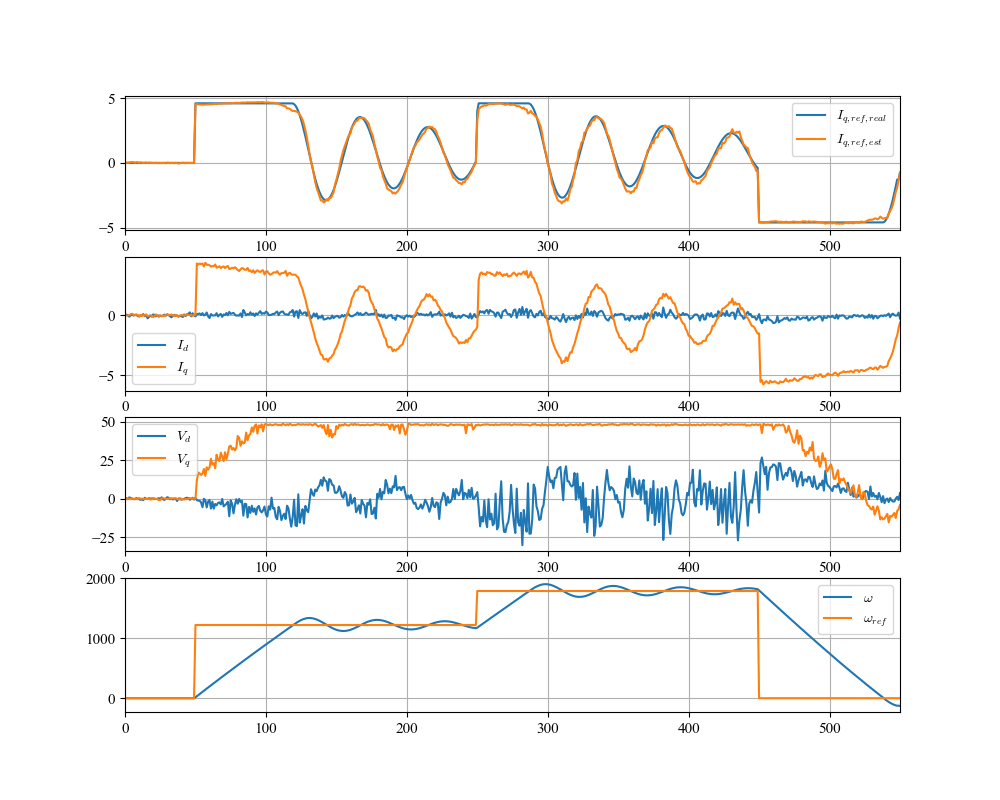

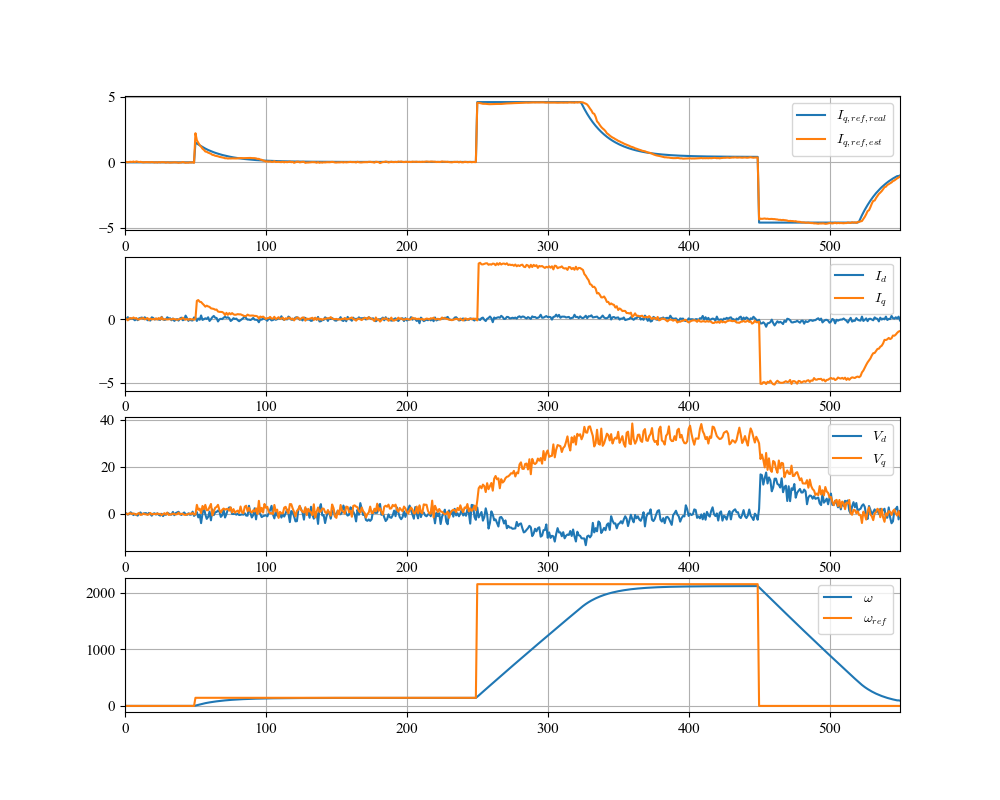

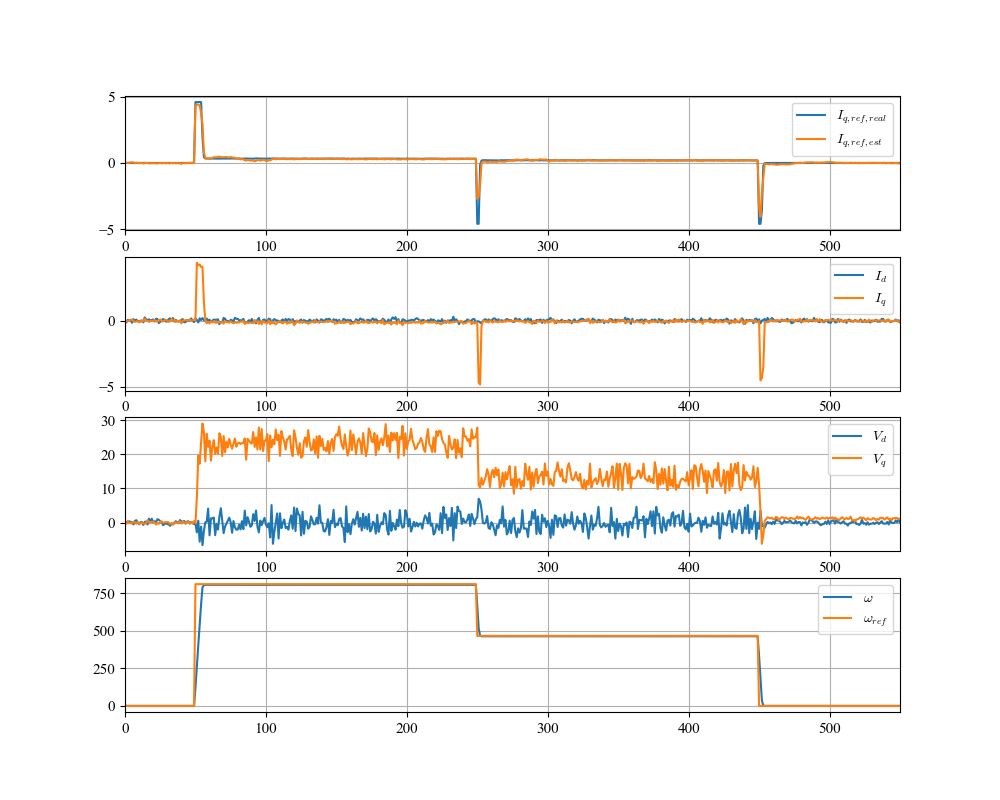

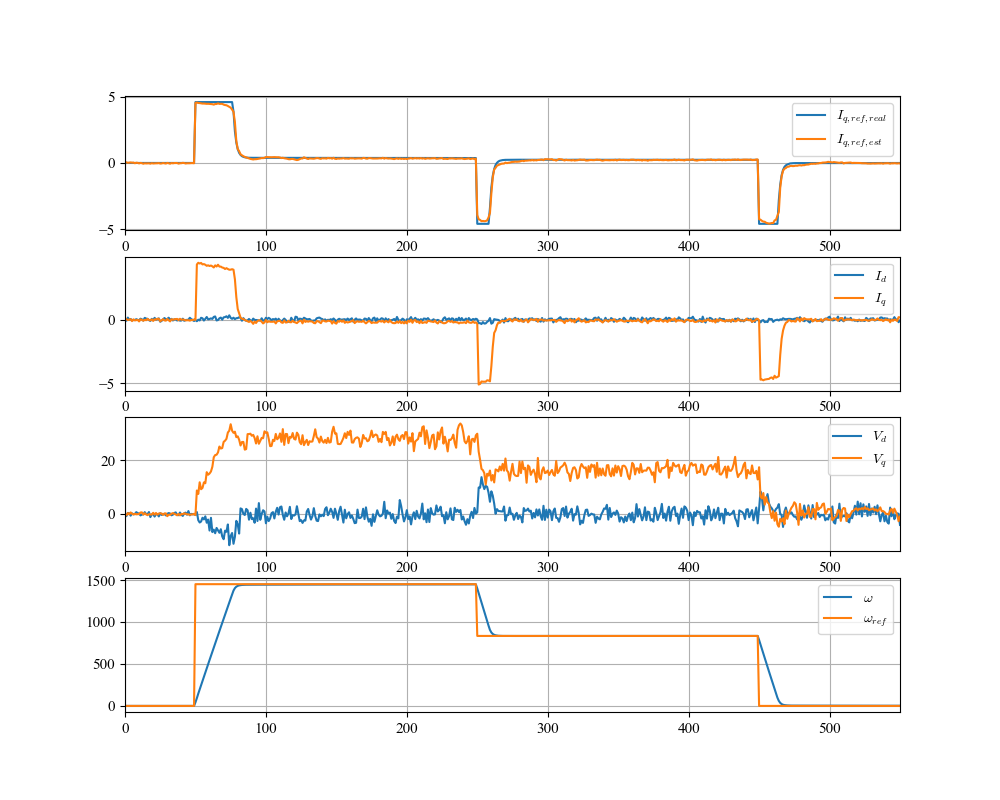

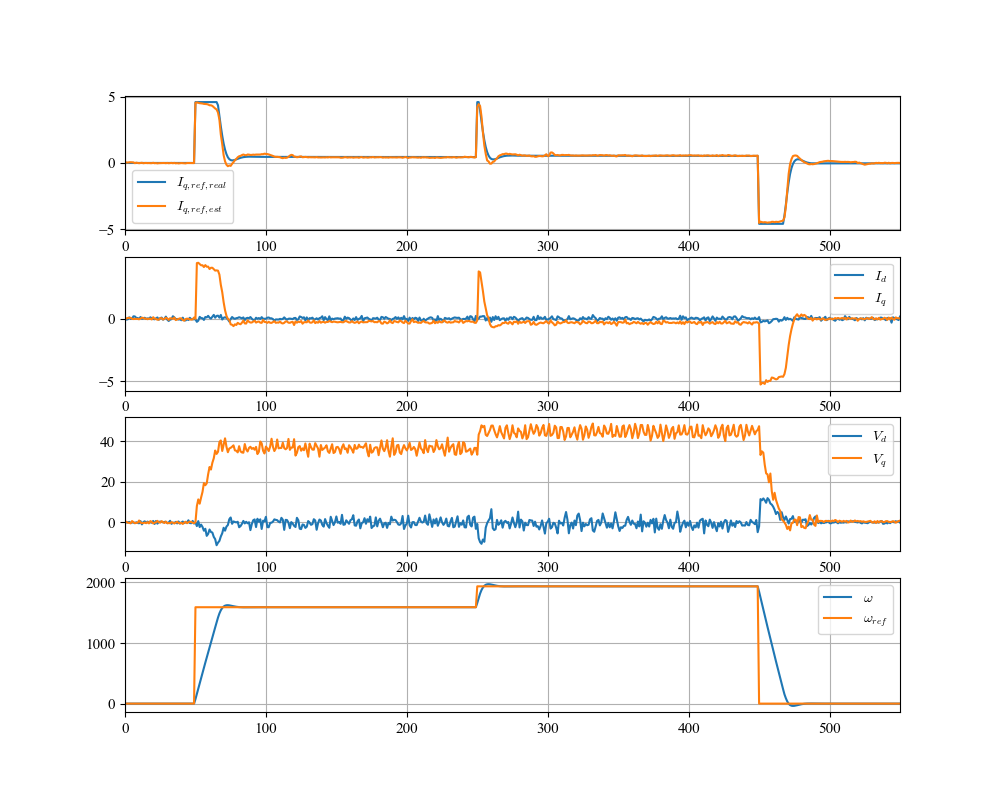

In [34]:
# show the first 10 experiments
for i in range(10):

    y_full_np = y_full_all.cpu().numpy()
    y_pred_np = y_pred_all.cpu().numpy()
    u_full_np = u_full_all.cpu().numpy()

    # print(y_full_np.shape)
    # print(u_full_np.shape)
    fig = plt.figure(figsize=(10,8))
    ax1 = fig.add_subplot(4,1,1)
    ax1.plot(y_full_np[i])
    ax1.plot(y_pred_np[i])
    ax1.legend([r'$I_{q,ref,real}$',r'$I_{q,ref,est}$'])
    ax2 = fig.add_subplot(4,1,2, sharex=ax1)
    ax2.plot(u_full_np[i,:,0])
    ax2.plot(u_full_np[i,:,1])
    ax2.legend([r'$I_{d}$',r'$I_{q}$'])
    ax3 = fig.add_subplot(4,1,3, sharex=ax1)
    ax3.plot(u_full_np[i,:,2])
    ax3.plot(u_full_np[i,:,3])
    ax3.legend([r'$V_{d}$',r'$V_{q}$'])
    ax4 = fig.add_subplot(4,1,4, sharex=ax1)
    ax4.plot(u_full_np[i,:,4])
    ax4.plot(u_full_np[i,:,5])
    ax4.legend([r'$\omega$',r'$\omega_{ref}$'])
    # ax5 = fig.add_subplot(5,2,9)
    # ax5.plot(u_full_np[i,:,6])
    # ax5.legend([r'$T_{ass}$'])
    # ax6 = fig.add_subplot(5,2,10)
    # ax6.plot(u_full_np[i,:,7])
    # ax6.legend([r'$S_{pct}$'])


    plt.show()
    

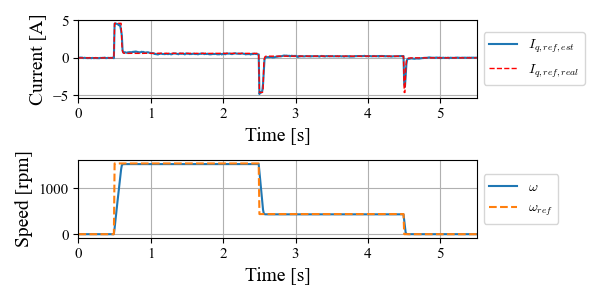

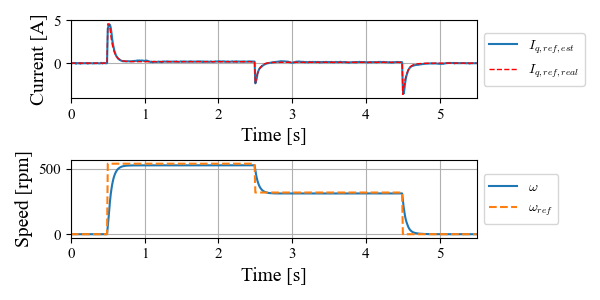

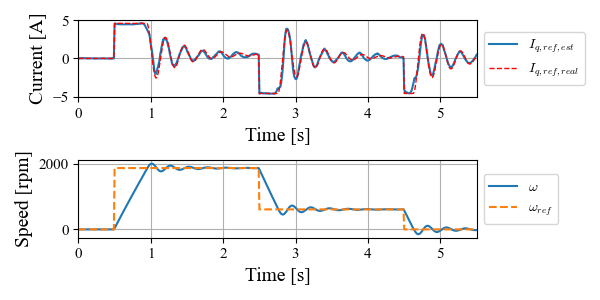

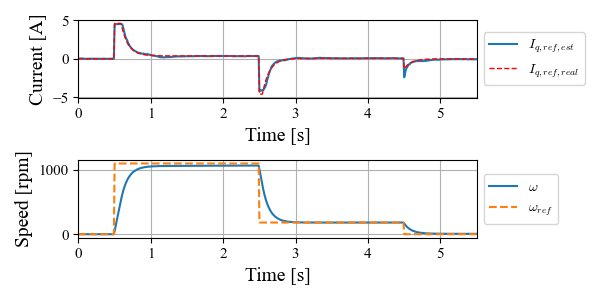

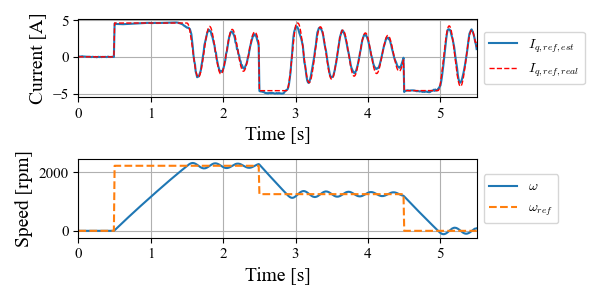

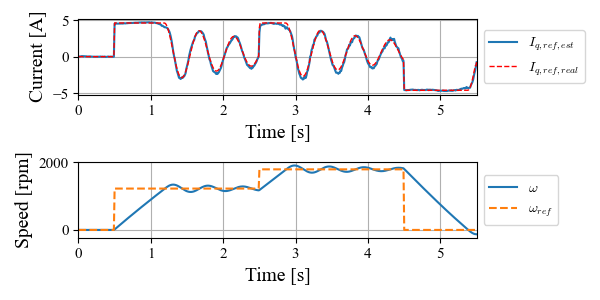

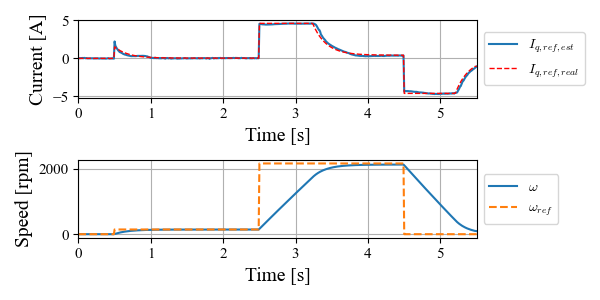

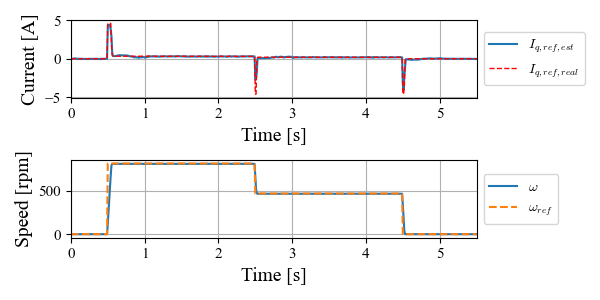

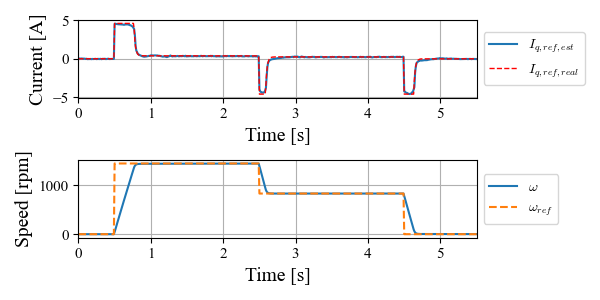

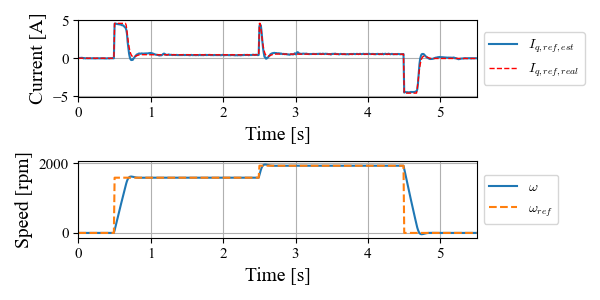

In [35]:
# show the first 10 experiments currents / speed only

y_full_np = y_full_all.cpu().numpy()
y_pred_np = y_pred_all.cpu().numpy()
u_full_np = u_full_all.cpu().numpy()
time_step = np.arange(len(y_full_np[0]))*0.01
for i in range(10):

    # print(y_full_np.shape)
    # print(u_full_np.shape)
    fig = plt.figure(figsize=(6,3))
    ax1 = fig.add_subplot(2,1,1)
    ax1.plot(time_step,y_pred_np[i])
    ax1.plot(time_step,y_full_np[i], '--', linewidth = 1, color = 'r')
    ax1.set(xlabel=r'Time [s]', ylabel=r'Current [A]')
    ax1.legend([r'$I_{q,ref,est}$',r'$I_{q,ref,real}$'], loc='center left', bbox_to_anchor=(1, 0.5))
    ax2 = fig.add_subplot(2,1,2, sharex=ax1)
    ax2.plot(time_step,u_full_np[i,:,4])
    ax2.plot(time_step,u_full_np[i,:,5], '--')
    ax2.set(xlabel=r'Time [s]', ylabel=r'Speed [rpm]')
    ax2.legend([r'$\omega$',r'$\omega_{ref}$'], loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()


    plt.show()
    

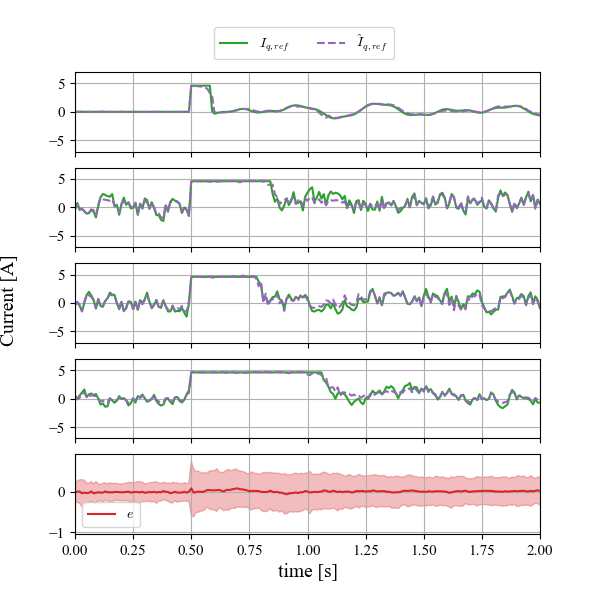

In [36]:
# Convert batch tensors to numpy for plotting
np.random.seed(11)
plot_order = np.arange(df_len)
np.random.shuffle(plot_order)



y_full_np = y_full_all.cpu().numpy()
y_pred_np = y_pred_all.cpu().numpy()
time_fig = np.arange(len(y_full_np[0]))*0.01

# Plotting
fig, axes = plt.subplots(5, 1, figsize=(6, 6), sharex=True)

# Plotting in each subplot
for i in range(4):
    axes[i].plot(time_fig, y_full_np[plot_order[i]], label=r"$I_{q,ref}$", color="tab:green")
    axes[i].plot(time_fig, y_pred_np[plot_order[i]], label=r"$\hat{I}_{q,ref}$", color="tab:purple", linestyle="--")
    axes[i].set_ylim([-7, 7])
axes[0].legend(bbox_to_anchor=(0.7, 1.65), ncols=2)

mean_error = (y_full_np - y_pred_np).mean(axis=0).flatten()
std_error = (y_full_np - y_pred_np).std(axis=0).flatten()
# mse = ((batch_y_np - batch_y_pred_np)**2).mean()

axes[-1].plot(time_fig, mean_error, label="$e$", color="tab:red")
axes[-1].fill_between(
    time_fig, 
    mean_error + std_error, 
    mean_error - std_error, 
    color='tab:red', 
    alpha=0.3
)
axes[-1].legend()
axes[-1].set_xlim([0, 2])

# Set the x-label for the last subplot
axes[-1].set_xlabel('time [s]')
# Add a common ylabel
fig.text(0.0, 0.5, 'Current [A]', va='center', rotation='vertical', fontsize=14)
# plt.savefig('prediction.pdf')
plt.show()